# 02 — Model Evaluation (v2, NO LEAKAGE)

Evaluate models trained up to 2024-06-30 on genuinely unseen data (2024-07 to 2025-12).

## Tests
1. **Direction accuracy** — by horizon, threshold, and pair
2. **Calibration curves** — does predicted P(down) match actual frequency?
3. **Prediction stability** — confidence distribution over time
4. **Momentum baseline comparison** — alpha over simple LR

In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

DARK = '#080c14'
BLUE = '#4fc3f7'
GOLD = '#ffd700'
RED  = '#ef5350'
GREEN = '#66bb6a'

DATA_DIR   = Path('../backend/data/features')
MODELS_DIR = Path('../backend/models_2')

HORIZONS       = ['1H', '4H', '1D', '7D']
QUANTILES      = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_NAMES = ['Q10', 'Q25', 'Q50', 'Q75', 'Q90']
PAIRS          = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']

TRAIN_END = '2024-06-30'


print('Loading data...')
df = pd.read_parquet(DATA_DIR / 'all_pairs_features_labels.parquet')
df.index = pd.to_datetime(df.index)

label_cols   = [f'label_{h}' for h in HORIZONS]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

df_train = df[df.index <= TRAIN_END]
df_test  = df[df.index > TRAIN_END]

print(f'Full:  {len(df):,} rows  ({df.index.min().date()} -> {df.index.max().date()})')
print(f'Train: {len(df_train):,} rows  (-> {TRAIN_END})')
print(f'Test:  {len(df_test):,} rows  ({df_test.index.min().date()} -> {df_test.index.max().date()})')
print(f'Features: {len(feature_cols)}')

Loading data...
Full:  685,111 rows  (2009-09-25 -> 2025-12-19)
Train: 622,579 rows  (-> 2024-06-30)
Test:  62,532 rows  (2024-07-01 -> 2025-12-19)
Features: 208


In [4]:
# Load v2 models
models = {}
for horizon in HORIZONS:
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        models[(horizon, q_name)] = bundle['model']

print(f'Loaded {len(models)} models from {MODELS_DIR}')

Loaded 20 models from ..\backend\models_2


In [5]:
# Shared helpers

def derive_p_down(q_vals):
    qs = np.array(QUANTILES)
    vals = np.sort(q_vals)
    if vals[0] <= 0 <= vals[-1]:
        return float(np.interp(0, vals, qs))
    elif vals[-1] < 0:
        slope = (qs[-1] - qs[-2]) / (vals[-1] - vals[-2] + 1e-10)
        return float(np.clip(qs[-1] + slope * (0 - vals[-1]), 0.90, 0.999))
    else:
        slope = (qs[1] - qs[0]) / (vals[1] - vals[0] + 1e-10)
        return float(np.clip(qs[0] + slope * (0 - vals[0]), 0.001, 0.10))


def get_predictions(df_subset, horizon):
    """Run inference on a DataFrame subset. Returns p_cal, p_dom, correct, y."""
    X = df_subset[feature_cols].ffill().bfill()
    y = df_subset[f'label_{horizon}'].values

    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        q_preds[q_name] = models[(horizon, q_name)].predict(X)

    p_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])

    # No calibrator for v2 yet — use raw p_down as p_cal
    p_cal = p_raw
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y < 0, y > 0)

    return p_cal, p_dom, correct, y


def accuracy_at_threshold(p_dom, correct, threshold=0.70):
    mask = p_dom >= threshold
    if mask.sum() < 10:
        return float('nan'), 0
    return correct[mask].mean(), mask.sum()


print('Helpers ready.')

Helpers ready.


---
## TEST 1 — Direction Accuracy on Unseen Test Set (2024-07 to 2025-12)

In [6]:
print('TEST 1 — Direction Accuracy on UNSEEN test set')
print(f'Test period: {df_test.index.min().date()} to {df_test.index.max().date()}')
print(f'These models have NEVER seen this data.')
print('=' * 70)

print(f'\n{"Horizon":<8} {"Threshold":<12} {"Accuracy":<12} {"Frequency":<12} {"N samples"}')
print('-' * 56)

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    df_sub = df_test.iloc[::step]
    p_cal, p_dom, correct, y = get_predictions(df_sub, horizon)

    for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        acc, n = accuracy_at_threshold(p_dom, correct, thresh)
        freq = (p_dom >= thresh).mean()
        print(f'{horizon:<8} >={thresh:.0%}      {acc:<12.1%} {freq:<12.1%} {n}')
    print()

TEST 1 — Direction Accuracy on UNSEEN test set
Test period: 2024-07-01 to 2025-12-19
These models have NEVER seen this data.

Horizon  Threshold    Accuracy     Frequency    N samples
--------------------------------------------------------
1H       >=55%      77.9%        83.3%        52119
1H       >=60%      82.1%        70.1%        43861
1H       >=65%      85.7%        60.4%        37750
1H       >=70%      88.1%        53.3%        33306
1H       >=75%      89.9%        47.4%        29646
1H       >=80%      92.9%        38.2%        23911

4H       >=55%      77.9%        87.6%        13692
4H       >=60%      81.5%        75.9%        11860
4H       >=65%      84.1%        66.3%        10358
4H       >=70%      86.4%        57.9%        9046
4H       >=75%      88.5%        49.9%        7801
4H       >=80%      92.4%        37.7%        5897

1D       >=55%      75.6%        72.8%        1896
1D       >=60%      81.0%        57.3%        1494
1D       >=65%      84.7%        4

---
## TEST 2 — Pair-by-Pair Accuracy Breakdown

In [7]:
print('TEST 2 — PAIR-BY-PAIR ACCURACY on unseen test set')
print('=' * 70)

results = []

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    print(f'\nHorizon: {horizon}')
    print(f'  {"Pair":<10} {"Overall":<12} {">=70% acc":<12} {">=70% freq":<12} {"N"}')
    print(f'  {"-"*50}')

    for pair in PAIRS:
        df_pair = df_test[df_test['pair'] == pair].iloc[::step]
        if len(df_pair) < 50:
            continue

        p_cal, p_dom, correct, y = get_predictions(df_pair, horizon)

        overall_acc = correct.mean()
        acc_70, n_70 = accuracy_at_threshold(p_dom, correct, 0.70)
        freq_70 = (p_dom >= 0.70).mean()

        print(f'  {pair:<10} {overall_acc:<12.1%} {acc_70:<12.1%} {freq_70:<12.1%} {n_70}')
        results.append({'horizon': horizon, 'pair': pair, 'overall': overall_acc,
                        'acc_70': acc_70, 'freq_70': freq_70})

df_results = pd.DataFrame(results)
print(f'\nBest pair overall: {df_results.groupby("pair")["overall"].mean().idxmax()}')
print(f'Best pair >=70%:   {df_results.groupby("pair")["acc_70"].mean().idxmax()}')

TEST 2 — PAIR-BY-PAIR ACCURACY on unseen test set

Horizon: 1H
  Pair       Overall      >=70% acc    >=70% freq   N
  --------------------------------------------------
  EURUSD     73.6%        88.5%        53.1%        4739
  GBPUSD     73.0%        87.9%        53.0%        4744
  USDJPY     73.5%        87.8%        53.5%        4787
  USDCHF     72.8%        87.7%        53.3%        4769
  AUDUSD     73.5%        88.5%        54.0%        4776
  USDCAD     73.0%        88.4%        52.2%        4671
  NZDUSD     73.2%        87.8%        53.9%        4825

Horizon: 4H
  Pair       Overall      >=70% acc    >=70% freq   N
  --------------------------------------------------
  EURUSD     76.2%        87.8%        59.3%        1323
  GBPUSD     77.4%        88.7%        61.2%        1368
  USDJPY     78.0%        88.2%        61.2%        1370
  USDCHF     76.1%        87.2%        59.9%        1340
  AUDUSD     73.3%        86.3%        55.4%        1225
  USDCAD     74.7%        

---
## TEST 3 — Calibration Curves (Raw P(down) vs Actual)

TEST 3 — Calibration on unseen test set
1H: MCE=0.015  n=62,532
4H: MCE=0.016  n=15,633
1D: MCE=0.030  n=2,606
7D: MCE=0.053  n=373


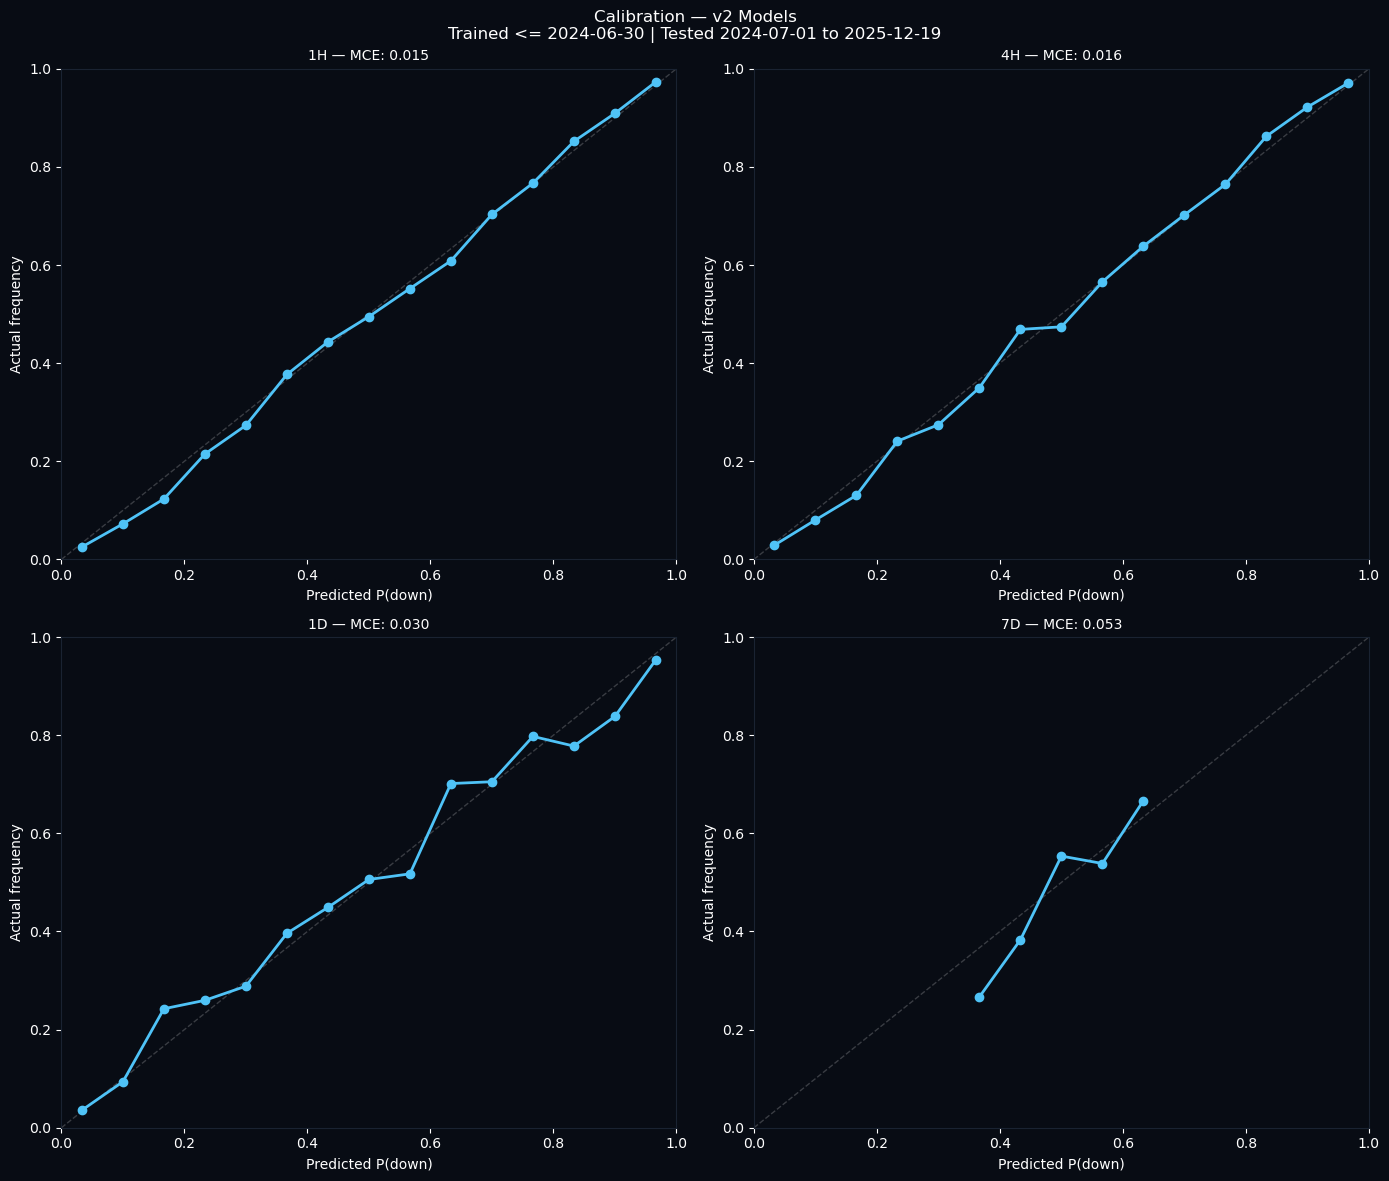

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor(DARK)

print('TEST 3 — Calibration on unseen test set')
print('=' * 55)

for idx, (horizon, step) in enumerate([('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor(DARK)

    df_sub = df_test.iloc[::step]
    p_cal, p_dom, correct, y = get_predictions(df_sub, horizon)
    y_binary = (y < 0).astype(float)

    # Bin predictions into deciles
    n_bins = 15
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_actuals = []

    for i in range(n_bins):
        mask = (p_cal >= bins[i]) & (p_cal < bins[i+1])
        if mask.sum() >= 10:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            bin_actuals.append(y_binary[mask].mean())

    ax.plot([0, 1], [0, 1], '--', color=(1, 1, 1, 0.2), linewidth=1)
    ax.plot(bin_centers, bin_actuals, 'o-', color=BLUE, linewidth=2, markersize=6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted P(down)', color='white')
    ax.set_ylabel('Actual frequency', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

    mce = np.mean(np.abs(np.array(bin_actuals) - np.array(bin_centers)))
    ax.set_title(f'{horizon} — MCE: {mce:.3f}', color='white', fontsize=10)
    print(f'{horizon}: MCE={mce:.3f}  n={len(df_sub):,}')

plt.suptitle(f'Calibration — v2 Models\nTrained <= {TRAIN_END} | Tested {df_test.index.min().date()} to {df_test.index.max().date()}',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

---
## TEST 4 — Prediction Stability Over Time

TEST 4 — Prediction Stability on test set
1H: >=90%=24.0%  >=70%=53.1%  <60%=30.3%  std=0.170
4H: >=90%=22.0%  >=70%=59.9%  <60%=23.5%  std=0.159
1D: >=90%=24.7%  >=70%=43.8%  <60%=42.9%  std=0.186
7D: >=90%=0.0%  >=70%=1.1%  <60%=90.0%  std=0.043


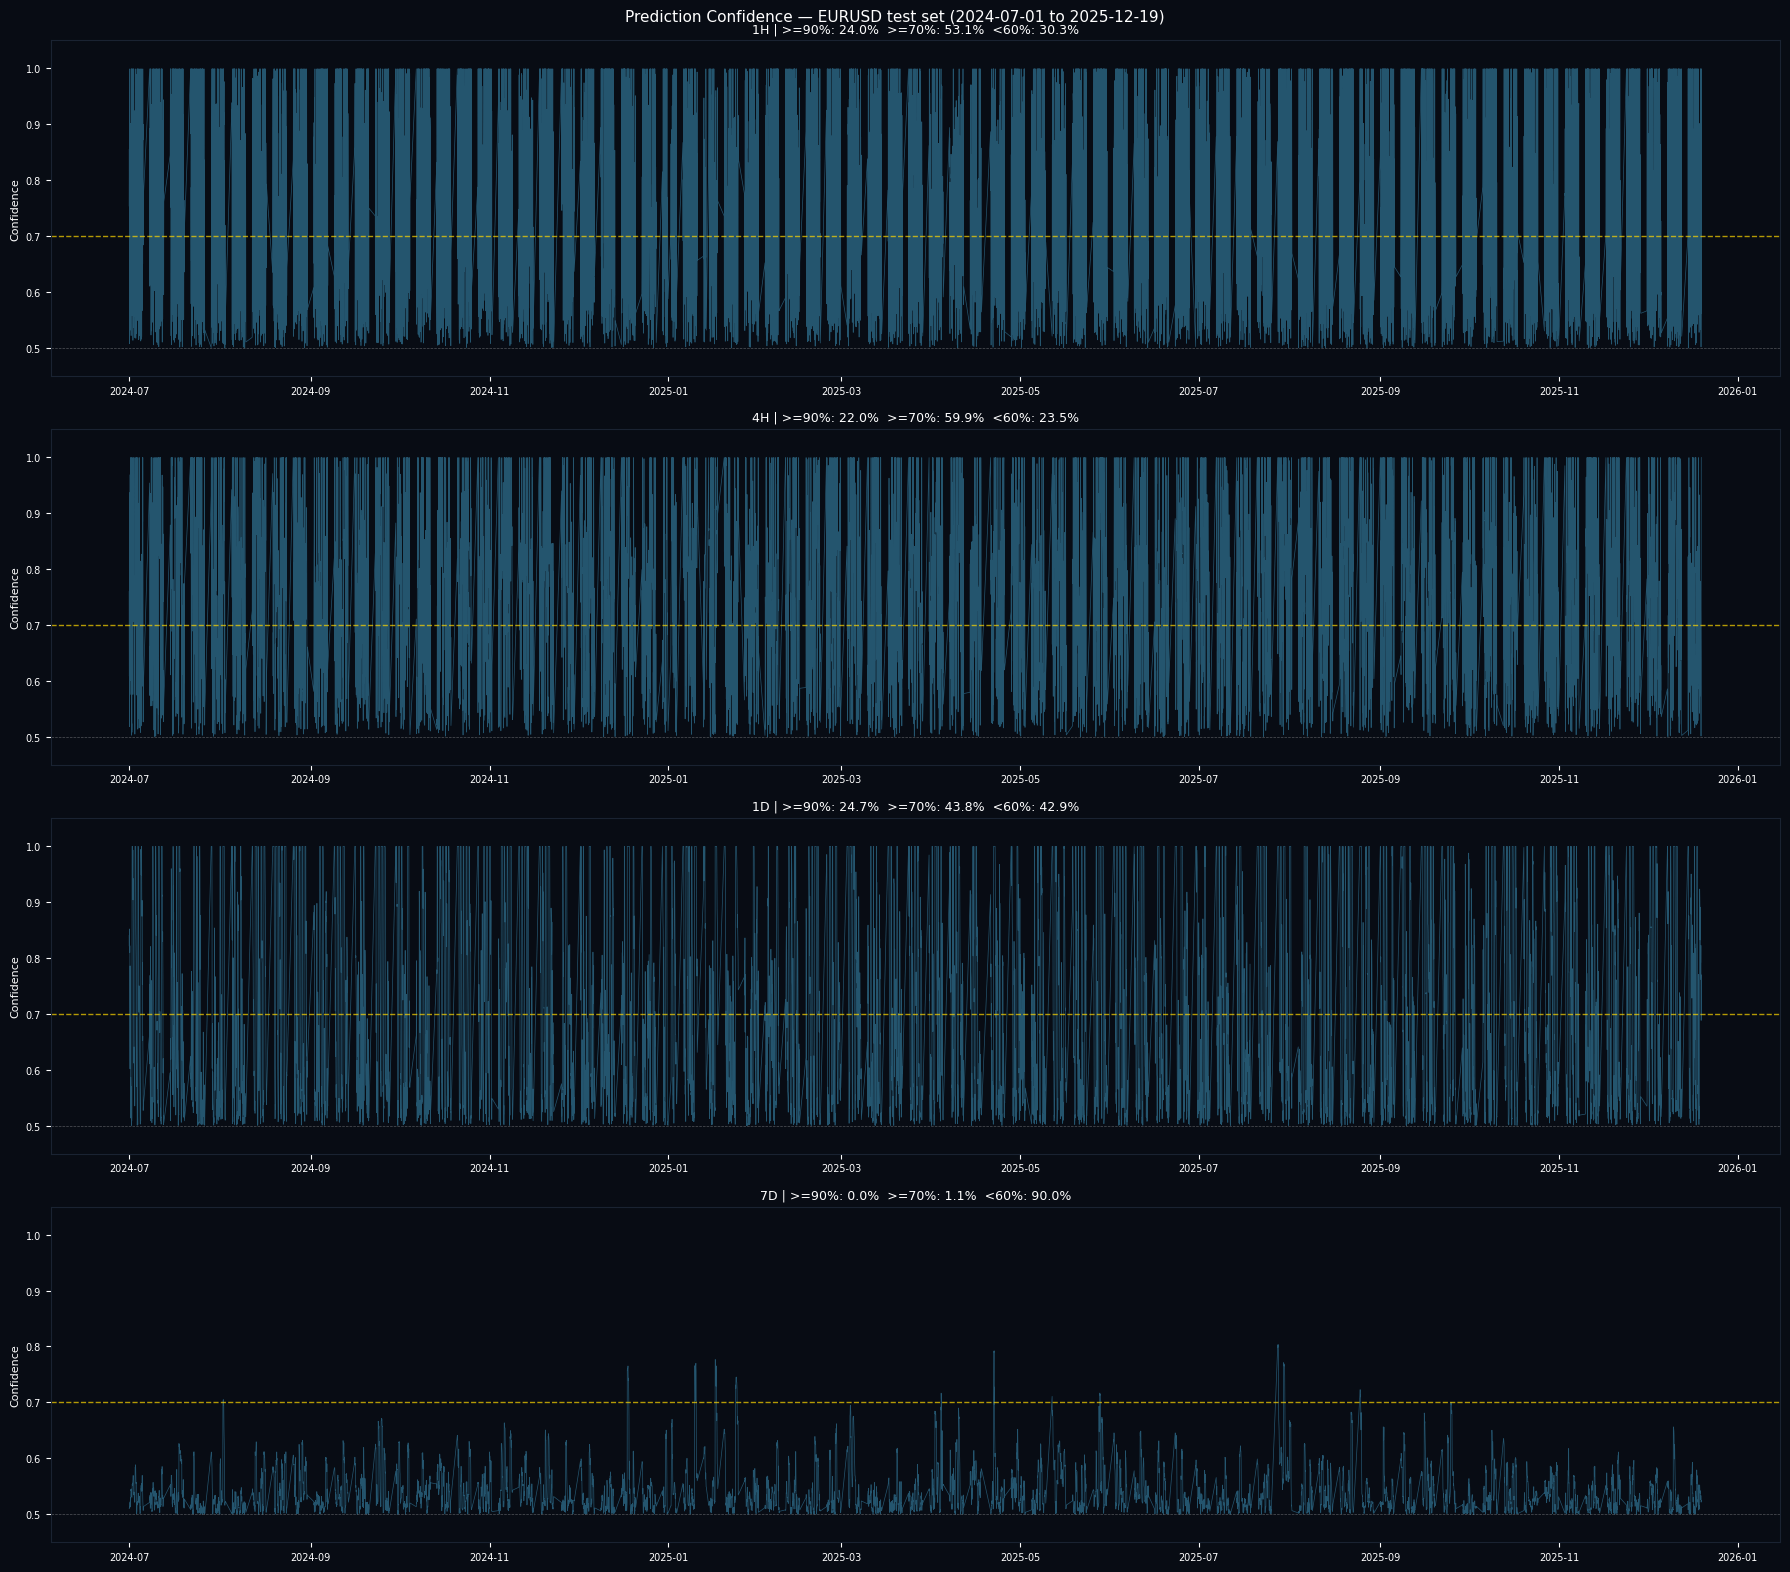

In [9]:
print('TEST 4 — Prediction Stability on test set')
print('=' * 60)

df_eu_test = df_test[df_test['pair'] == 'EURUSD']

fig, axes = plt.subplots(4, 1, figsize=(18, 16))
fig.patch.set_facecolor(DARK)

for idx, horizon in enumerate(HORIZONS):
    ax = axes[idx]
    ax.set_facecolor(DARK)

    p_cal, p_dom, correct, y = get_predictions(df_eu_test, horizon)

    ax.plot(df_eu_test.index, p_dom, color=BLUE, alpha=0.4, linewidth=0.5)
    ax.axhline(0.70, color=GOLD, linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_ylim(0.45, 1.05)
    ax.set_ylabel('Confidence', color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

    pct_above_90 = (p_dom >= 0.90).mean()
    pct_above_70 = (p_dom >= 0.70).mean()
    pct_below_60 = (p_dom < 0.60).mean()
    ax.set_title(
        f'{horizon} | >=90%: {pct_above_90:.1%}  >=70%: {pct_above_70:.1%}  <60%: {pct_below_60:.1%}',
        color='white', fontsize=9
    )
    print(f'{horizon}: >=90%={pct_above_90:.1%}  >=70%={pct_above_70:.1%}  <60%={pct_below_60:.1%}  std={p_dom.std():.3f}')

plt.suptitle(f'Prediction Confidence — EURUSD test set ({df_eu_test.index.min().date()} to {df_eu_test.index.max().date()})',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

---
## TEST 5 — Momentum Baseline Comparison

In [10]:
momentum_cols = [c for c in feature_cols if 'log_ret' in c and '1H' in c]
momentum_cols += [c for c in feature_cols if 'rsi_14_1H' in c or 'macd_hist_1H' in c or 'rvol_24_1H' in c]

df_eu_train = df_train[df_train['pair'] == 'EURUSD']
df_eu_test  = df_test[df_test['pair'] == 'EURUSD']

print(f'Momentum features: {len(momentum_cols)}')
print(f'\nLR MOMENTUM BASELINE vs v2 MODELS — EURUSD, unseen test set')
print('=' * 65)

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    y_train_lr = (df_eu_train[f'label_{horizon}'].values < 0).astype(int)
    y_test_lr  = (df_eu_test.iloc[::step][f'label_{horizon}'].values < 0).astype(int)

    X_train_lr = df_eu_train[momentum_cols].ffill().bfill().values
    X_test_lr  = df_eu_test.iloc[::step][momentum_cols].ffill().bfill().values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_lr)
    X_test_s  = scaler.transform(X_test_lr)

    lr = LogisticRegression(max_iter=1000, C=0.1)
    lr.fit(X_train_s, y_train_lr)
    lr_acc = (lr.predict(X_test_s) == y_test_lr).mean()

    # v2 model accuracy
    p_cal, p_dom, correct, _ = get_predictions(df_eu_test.iloc[::step], horizon)
    v2_acc = correct.mean()
    alpha = v2_acc - lr_acc

    print(f'{horizon}: LR baseline={lr_acc:.1%}  v2 model={v2_acc:.1%}  Alpha={alpha:+.1%}')

Momentum features: 8

LR MOMENTUM BASELINE vs v2 MODELS — EURUSD, unseen test set
1H: LR baseline=52.3%  v2 model=73.6%  Alpha=+21.3%
4H: LR baseline=51.7%  v2 model=76.2%  Alpha=+24.6%
1D: LR baseline=49.2%  v2 model=75.0%  Alpha=+25.8%
7D: LR baseline=46.3%  v2 model=63.0%  Alpha=+16.7%


---
## TEST 6 — Rolling Accuracy (detect regime decay)

TEST 6 — Rolling 30-day accuracy on test set


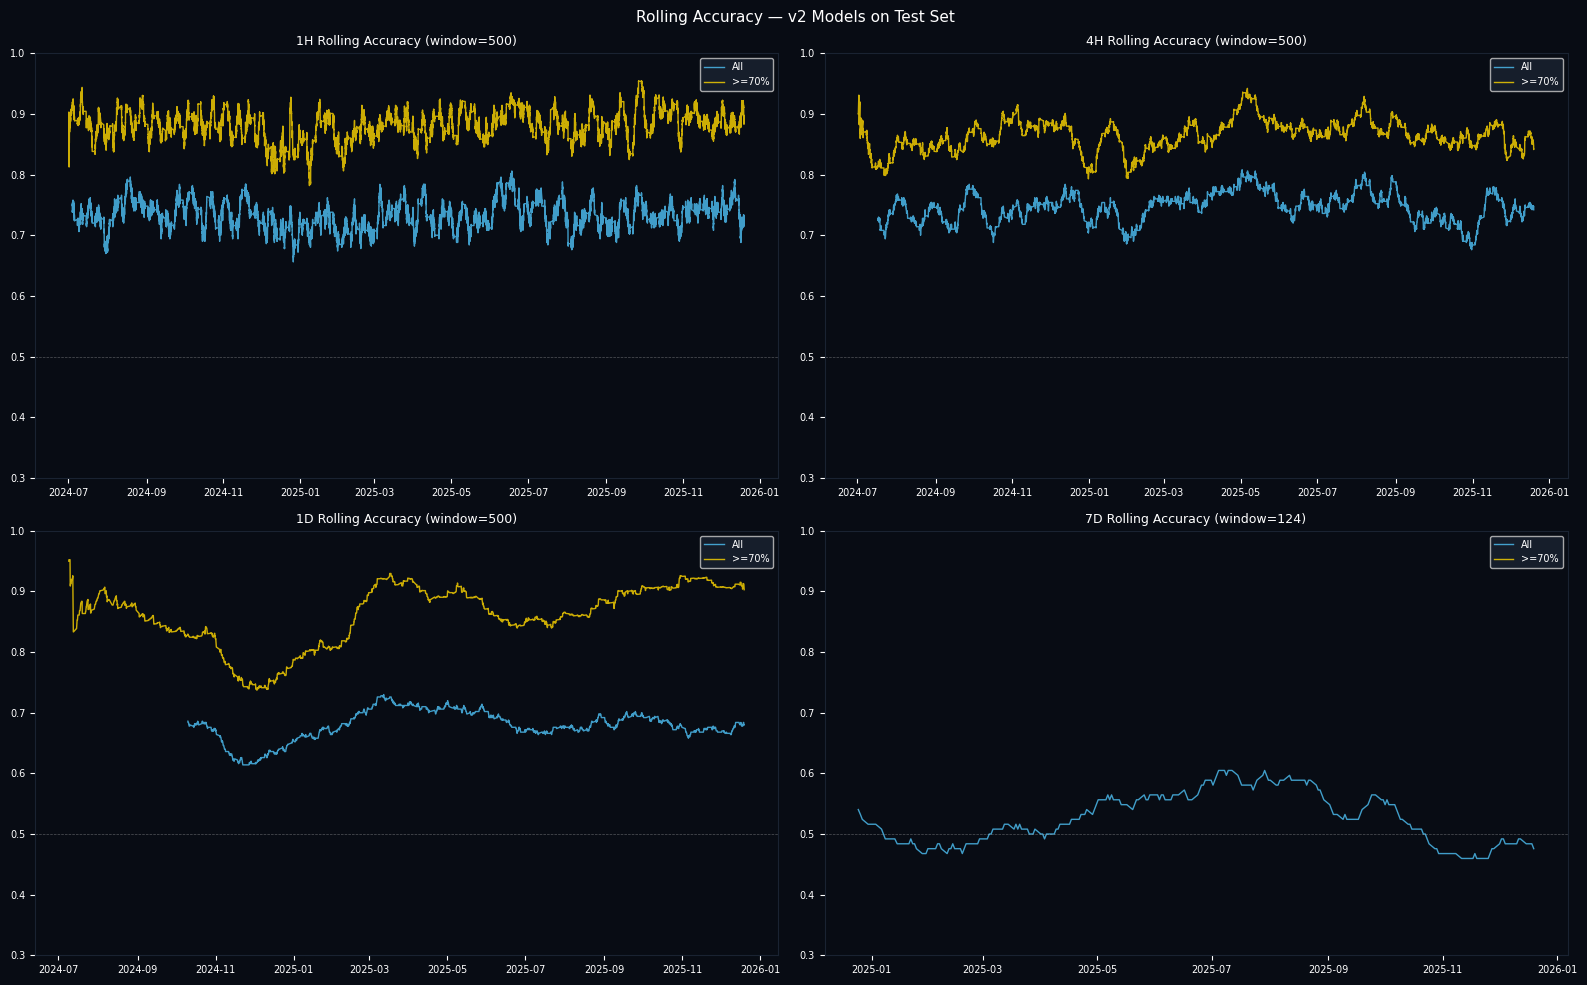

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK)

print('TEST 6 — Rolling 30-day accuracy on test set')
print('=' * 55)

for idx, (horizon, step) in enumerate([('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor(DARK)

    df_sub = df_test.iloc[::step]
    p_cal, p_dom, correct, y = get_predictions(df_sub, horizon)

    # Rolling accuracy (30-day windows)
    window = min(500, len(correct) // 3)
    if window < 30:
        window = 30
    rolling_acc = pd.Series(correct.astype(float), index=df_sub.index).rolling(window).mean()
    rolling_acc_70 = pd.Series(
        np.where(p_dom >= 0.70, correct.astype(float), np.nan),
        index=df_sub.index
    ).rolling(window, min_periods=20).mean()

    ax.plot(rolling_acc.index, rolling_acc, color=BLUE, linewidth=1, alpha=0.8, label='All')
    ax.plot(rolling_acc_70.index, rolling_acc_70, color=GOLD, linewidth=1, alpha=0.8, label='>=70%')
    ax.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_ylim(0.3, 1.0)
    ax.set_title(f'{horizon} Rolling Accuracy (window={window})', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    ax.legend(facecolor='#1a2332', labelcolor='white', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

plt.suptitle(f'Rolling Accuracy — v2 Models on Test Set', color='white', fontsize=11)
plt.tight_layout()
plt.show()

## TEST 7 — Permutation Test

In [12]:
# PERMUTATION TEST — does accuracy collapse with shuffled labels?
# If real model >> permuted model, the edge is genuine (not a structural artifact).
import numpy as np
from sklearn.utils import shuffle

print('PERMUTATION TEST — 200 random label shuffles')
print('=' * 55)

N_PERMS = 200

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24)]:
    df_sub = df_test.iloc[::step]
    p_cal, p_dom, correct, y = get_predictions(df_sub, horizon)
    real_acc = correct.mean()
    real_acc_70, _ = accuracy_at_threshold(p_dom, correct, 0.70)

    perm_accs = []
    perm_accs_70 = []
    for _ in range(N_PERMS):
        y_shuf = shuffle(y, random_state=None)
        c_shuf = np.where(p_cal > 0.5, y_shuf < 0, y_shuf > 0)
        perm_accs.append(c_shuf.mean())
        mask_70 = p_dom >= 0.70
        if mask_70.sum() >= 10:
            perm_accs_70.append(c_shuf[mask_70].mean())

    perm_mean = np.mean(perm_accs)
    perm_std  = np.std(perm_accs)
    z_score   = (real_acc - perm_mean) / perm_std
    p_value   = (np.array(perm_accs) >= real_acc).mean()

    perm_mean_70 = np.mean(perm_accs_70)
    z_score_70   = (real_acc_70 - perm_mean_70) / np.std(perm_accs_70) if perm_accs_70 else float('nan')

    print(f'\n{horizon}:')
    print(f'  Real accuracy:      {real_acc:.3f}')
    print(f'  Permuted mean/std:  {perm_mean:.3f} +/- {perm_std:.4f}')
    print(f'  Z-score:            {z_score:.2f}  (p={p_value:.4f})')
    print(f'  Real >=70% acc:     {real_acc_70:.3f}  permuted mean: {perm_mean_70:.3f}  Z={z_score_70:.2f}')
    verdict = 'GENUINE' if p_value < 0.01 else ('MARGINAL' if p_value < 0.05 else 'NOT SIGNIFICANT')
    print(f'  Verdict: {verdict}')


PERMUTATION TEST — 200 random label shuffles

1H:
  Real accuracy:      0.732
  Permuted mean/std:  0.496 +/- 0.0019
  Z-score:            123.98  (p=0.0000)
  Real >=70% acc:     0.881  permuted mean: 0.496  Z=157.97
  Verdict: GENUINE

4H:
  Real accuracy:      0.746
  Permuted mean/std:  0.498 +/- 0.0040
  Z-score:            61.38  (p=0.0000)
  Real >=70% acc:     0.864  permuted mean: 0.499  Z=68.38
  Verdict: GENUINE

1D:
  Real accuracy:      0.685
  Permuted mean/std:  0.500 +/- 0.0100
  Z-score:            18.45  (p=0.0000)
  Real >=70% acc:     0.864  permuted mean: 0.500  Z=24.07
  Verdict: GENUINE


---
## SUMMARY

In [13]:
print('=' * 70)
print('SUMMARY — v2 Models (NO LEAKAGE)')
print(f'Trained: 2009 to {TRAIN_END}')
print(f'Tested:  {df_test.index.min().date()} to {df_test.index.max().date()} (UNSEEN)')
print('=' * 70)

for horizon, step in [('1H', 1), ('4H', 4), ('1D', 24), ('7D', 168)]:
    df_sub = df_test.iloc[::step]
    p_cal, p_dom, correct, y = get_predictions(df_sub, horizon)

    overall = correct.mean()
    acc_70, n_70 = accuracy_at_threshold(p_dom, correct, 0.70)
    freq_70 = (p_dom >= 0.70).mean()
    acc_80, n_80 = accuracy_at_threshold(p_dom, correct, 0.80)

    print(f'\n{horizon}:')
    print(f'  Overall accuracy:  {overall:.1%}')
    print(f'  >=70% confidence:  {acc_70:.1%} accuracy ({freq_70:.1%} of predictions, n={n_70})')
    print(f'  >=80% confidence:  {acc_80:.1%} accuracy (n={n_80})')

SUMMARY — v2 Models (NO LEAKAGE)
Trained: 2009 to 2024-06-30
Tested:  2024-07-01 to 2025-12-19 (UNSEEN)

1H:
  Overall accuracy:  73.2%
  >=70% confidence:  88.1% accuracy (53.3% of predictions, n=33306)
  >=80% confidence:  92.9% accuracy (n=23911)

4H:
  Overall accuracy:  74.6%
  >=70% confidence:  86.4% accuracy (57.9% of predictions, n=9046)
  >=80% confidence:  92.4% accuracy (n=5897)

1D:
  Overall accuracy:  68.5%
  >=70% confidence:  86.4% accuracy (42.2% of predictions, n=1099)
  >=80% confidence:  90.1% accuracy (n=826)

7D:
  Overall accuracy:  53.1%
  >=70% confidence:  nan% accuracy (2.1% of predictions, n=0)
  >=80% confidence:  nan% accuracy (n=0)
